# Exercise 1: Linear Classifiers

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn import model_selection
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 1. Exploring the Data

In [2]:
# Load the dataset
digits = load_digits()
print('Keys:', digits.keys())

data        = digits['data']
images      = digits['images']
target      = digits['target']
target_names = digits['target_names']

print(f'data shape:   {data.shape}   (N instances x 64 pixels)')
print(f'images shape: {images.shape} (N instances x 8 x 8 pixels)')
print(f'Each image is {images.shape[1]}x{images.shape[2]} pixels')

Keys: dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])
data shape:   (1797, 64)   (N instances x 64 pixels)
images shape: (1797, 8, 8) (N instances x 8 x 8 pixels)
Each image is 8x8 pixels


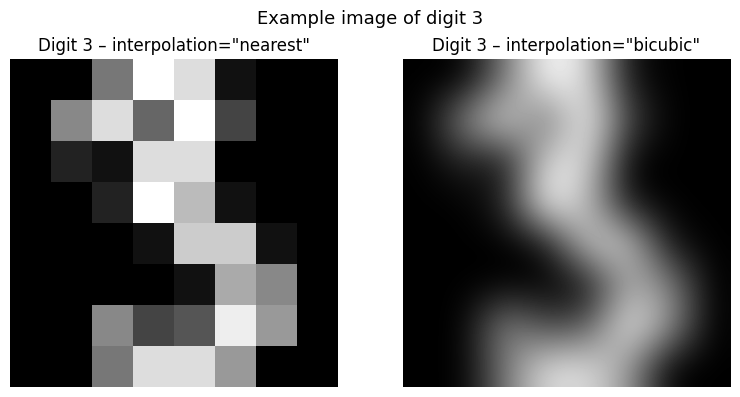

Image shape: (8, 8) (rows x cols)


In [3]:
# Visualize one image of digit '3' with two interpolation methods
idx3 = np.where(target == 3)[0][0]
img  = images[idx3]

assert 2 == len(img.shape), 'Image must be 2D'

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
for ax, interp in zip(axes, ['nearest', 'bicubic']):
    ax.imshow(img, cmap='gray', interpolation=interp)
    ax.set_title(f'Digit 3 – interpolation="{interp}"')
    ax.axis('off')
plt.suptitle('Example image of digit 3', fontsize=13)
plt.tight_layout()
plt.show()
print(f'Image shape: {img.shape} (rows x cols)')

In [4]:
# Filter to digits 3 and 9 only
mask = (target == 3) | (target == 9)
X_all = data[mask]
y_raw = target[mask]   # original labels (3 or 9)

# Use label -1 for digit 3 and +1 for digit 9 throughout
y_all = np.where(y_raw == 3, -1, 1)

print(f'Total samples (3 & 9): {X_all.shape[0]}')
print(f'  digit 3 (label -1): {(y_all == -1).sum()}')
print(f'  digit 9 (label +1): {(y_all ==  1).sum()}')

# Train / test split  (60 % train, 40 % test)
X_train, X_test, y_train, y_test = model_selection.train_test_split(
    X_all, y_all, test_size=0.4, random_state=0, stratify=y_all)

print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Test samples     : {X_test.shape[0]}')

Total samples (3 & 9): 363
  digit 3 (label -1): 183
  digit 9 (label +1): 180

Training samples : 217
Test samples     : 146


## 2. Hand-Crafted Classifier

### 2.1 Feature Construction

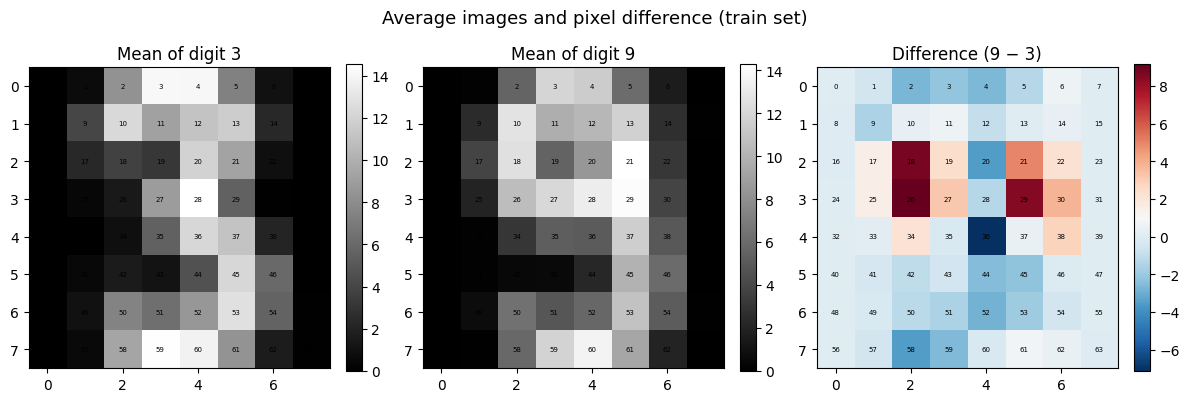

Pixel indices with largest absolute difference (most discriminative):
Index: [26 18 29 36 21 30 58 20 27 52] 
Value: [9.15 8.77 8.51 7.13 5.01 3.75 3.55 3.51 3.17 2.84]


In [5]:
# Average images per class to identify discriminative pixels
mean3 = X_train[y_train == -1].mean(axis=0).reshape(8, 8)
mean9 = X_train[y_train ==  1].mean(axis=0).reshape(8, 8)
diff  = mean9 - mean3          # positive → brighter in 9, negative → brighter in 3

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, img_data, title in zip(axes,
    [mean3, mean9, diff],
    ['Mean of digit 3', 'Mean of digit 9', 'Difference (9 − 3)']):
    im = ax.imshow(img_data, cmap='RdBu_r' if 'Diff' in title else 'gray',
                   interpolation='nearest')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046)
    # annotate pixel indices
    for r in range(8):
        for c in range(8):
            ax.text(c, r, str(r*8+c), ha='center', va='center',
                    fontsize=5, color='black')
plt.suptitle('Average images and pixel difference (train set)', fontsize=13)
plt.tight_layout()
plt.show()

print('Pixel indices with largest absolute difference (most discriminative):')
flat_diff = np.abs(diff.flatten())
top_idx   = flat_diff.argsort()[::-1][:10]
print('Index:', top_idx, '\nValue:', flat_diff[top_idx].round(2))

In [6]:
# Feature engineering
# Pixel 43 (row 5, col 3): bright in 9, dark in 3 → captures the bottom loop of 9
# Pixel 20 (row 2, col 4): bright in 3, dark in 9 → captures the top right of 3
# We combine several highly discriminative pixels linearly for each feature.

def features2d(x):
    """
    Map N×64 pixel matrix to N×2 feature matrix.
    Feature 1: captures bottom-center region (bright in 9, dark in 3)
    Feature 2: captures upper-right region (bright in 3, dark in 9)
    """
    x = np.asarray(x, dtype=float)
    # Feature 1 – weighted sum of pixels that are bright in 9
    f1 = (x[:, 43] + x[:, 44] + x[:, 35] + x[:, 36]) / 4.0
    # Feature 2 – weighted sum of pixels that are bright in 3
    f2 = (x[:, 20] + x[:, 21] + x[:, 28] + x[:, 13]) / 4.0
    features = np.column_stack([f1, f2])
    assert features.shape == (x.shape[0], 2)
    return features

# Compute features for train and test
F_train = features2d(X_train)
F_test  = features2d(X_test)
print(f'F_train shape: {F_train.shape}')
print(f'F_test  shape: {F_test.shape}')

F_train shape: (217, 2)
F_test  shape: (146, 2)


### 2.2 Scatter Plot

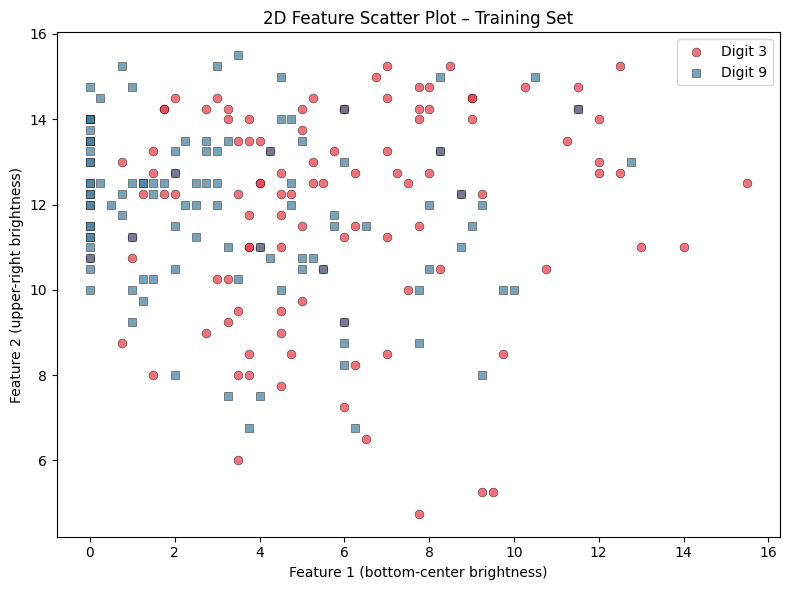

In [7]:
def scatter_classes(features, labels, title='', ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    colors = {-1: '#E63946', 1: '#457B9D'}
    markers = {-1: 'o', 1: 's'}
    for lbl, name in [(-1, 'Digit 3'), (1, 'Digit 9')]:
        mask = labels == lbl
        ax.scatter(features[mask, 0], features[mask, 1],
                   c=colors[lbl], marker=markers[lbl], alpha=0.7,
                   s=40, linewidths=0.4, edgecolors='k', label=name)
    ax.set_xlabel('Feature 1 (bottom-center brightness)')
    ax.set_ylabel('Feature 2 (upper-right brightness)')
    ax.set_title(title)
    ax.legend()
    return ax

fig, ax = plt.subplots(figsize=(8, 6))
scatter_classes(F_train, y_train, title='2D Feature Scatter Plot – Training Set', ax=ax)
plt.tight_layout()
plt.show()

### 2.3 Decision Rule – Nearest Mean Classifier

In [8]:
def nearest_mean(training_features, training_labels, test_features):
    """
    Assign each test instance to the class whose mean is nearest (Euclidean).
    Returns predicted labels (-1 or +1).
    """
    mu_neg = training_features[training_labels == -1].mean(axis=0)
    mu_pos = training_features[training_labels ==  1].mean(axis=0)

    dist_neg = np.linalg.norm(test_features - mu_neg, axis=1)
    dist_pos = np.linalg.norm(test_features - mu_pos, axis=1)

    return np.where(dist_neg < dist_pos, -1, 1)


def error_rate(y_true, y_pred):
    return (y_true != y_pred).mean()


# Nearest mean errors
pred_train_nm = nearest_mean(F_train, y_train, F_train)
pred_test_nm  = nearest_mean(F_train, y_train, F_test)

print('=== Nearest Mean Classifier ===')
print(f'Training error: {error_rate(y_train, pred_train_nm):.4f}')
print(f'Test error    : {error_rate(y_test,  pred_test_nm):.4f}')


# More sophisticated linear boundary via the closed-form LDA formula direction
# but with hand-tuned bias for illustration
mu_neg_2d = F_train[y_train == -1].mean(axis=0)
mu_pos_2d = F_train[y_train ==  1].mean(axis=0)

# β is the vector from mean_neg to mean_pos (perpendicular bisector direction)
beta_hand = mu_pos_2d - mu_neg_2d
b_hand    = -0.5 * (mu_pos_2d + mu_neg_2d) @ beta_hand

def linear_predict(X, beta, b):
    return np.sign(X @ beta + b)

pred_train_lin = linear_predict(F_train, beta_hand, b_hand)
pred_test_lin  = linear_predict(F_test,  beta_hand, b_hand)

print('\n=== Hand-crafted Linear Boundary (perpendicular bisector) ===')
print(f'Training error: {error_rate(y_train, pred_train_lin):.4f}')
print(f'Test error    : {error_rate(y_test,  pred_test_lin):.4f}')

=== Nearest Mean Classifier ===
Training error: 0.3641
Test error    : 0.3630

=== Hand-crafted Linear Boundary (perpendicular bisector) ===
Training error: 0.3641
Test error    : 0.3630


### 2.4 Visualize Decision Regions

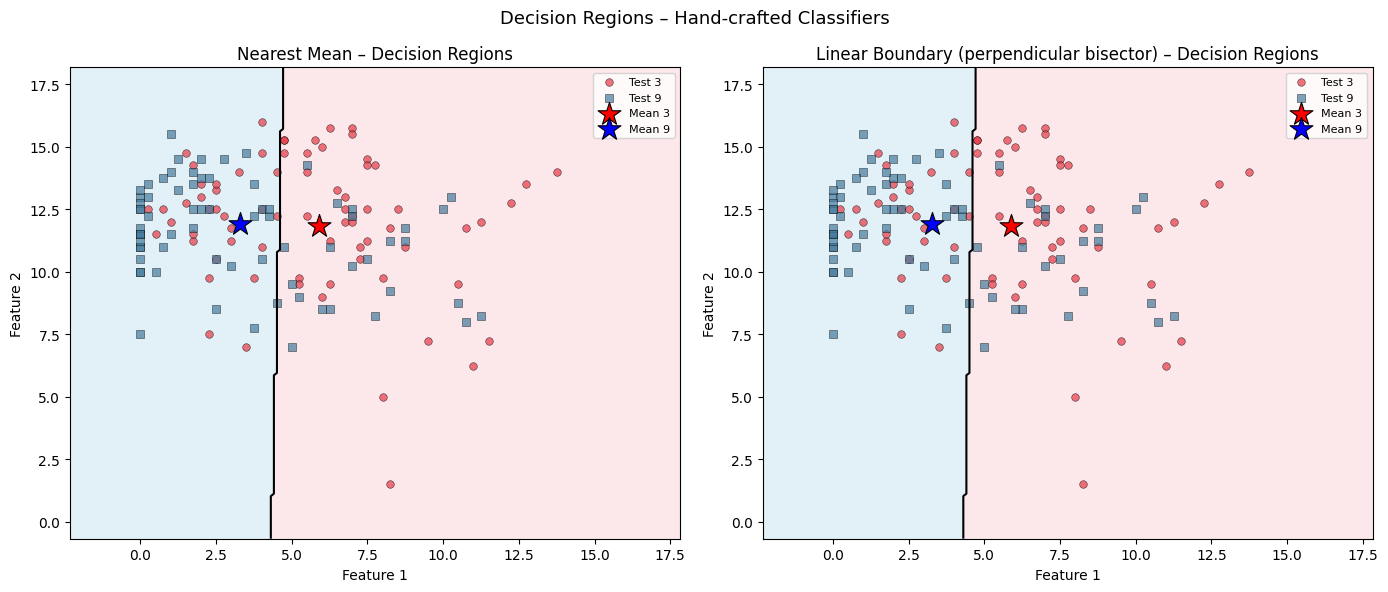

In [9]:
def make_grid(features, resolution=200, margin=0.15):
    """Create a 2D grid spanning the feature space with a margin."""
    f_min = features.min(axis=0)
    f_max = features.max(axis=0)
    rng   = f_max - f_min
    f_min -= margin * rng
    f_max += margin * rng
    g1 = np.linspace(f_min[0], f_max[0], resolution)
    g2 = np.linspace(f_min[1], f_max[1], resolution)
    G1, G2 = np.meshgrid(g1, g2)
    grid_pts = np.column_stack([G1.ravel(), G2.ravel()])
    return G1, G2, grid_pts, f_min, f_max


G1, G2, grid_pts, f_min, f_max = make_grid(
    np.vstack([F_train, F_test]), resolution=200)

# Predictions on the grid for nearest-mean and hand-crafted linear
Z_nm  = nearest_mean(F_train, y_train, grid_pts).reshape(G1.shape)
Z_lin = linear_predict(grid_pts, beta_hand, b_hand).reshape(G1.shape)

mu_neg_2d = F_train[y_train == -1].mean(axis=0)
mu_pos_2d = F_train[y_train ==  1].mean(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, Z, title in zip(axes,
    [Z_nm, Z_lin],
    ['Nearest Mean – Decision Regions',
     'Linear Boundary (perpendicular bisector) – Decision Regions']):

    # Decision region background
    ax.contourf(G1, G2, Z, levels=[-2, 0, 2],
                colors=['#FADADD', '#D0E8F2'], alpha=0.6)
    # Decision boundary
    ax.contour(G1, G2, Z, levels=[0], colors='k', linewidths=1.5)

    # Scatter test data
    for lbl, name, marker, color in [
            (-1, 'Test 3', 'o', '#E63946'),
            ( 1, 'Test 9', 's', '#457B9D')]:
        m = y_test == lbl
        ax.scatter(F_test[m, 0], F_test[m, 1], c=color, marker=marker,
                   s=30, alpha=0.7, edgecolors='k', linewidths=0.4, label=name)

    # Class means
    ax.scatter(*mu_neg_2d, c='red',  marker='*', s=300, zorder=5,
               edgecolors='k', linewidths=0.8, label='Mean 3')
    ax.scatter(*mu_pos_2d, c='blue', marker='*', s=300, zorder=5,
               edgecolors='k', linewidths=0.8, label='Mean 9')

    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.set_title(title)
    ax.legend(fontsize=8)

plt.suptitle('Decision Regions – Hand-crafted Classifiers', fontsize=13)
plt.tight_layout()
plt.show()

## 3. LDA

### 3.1 Implement LDA Training

In [10]:
def fit_lda(training_features, training_labels):
    """
    Fit LDA parameters.

    Parameters
    ----------
    training_features : ndarray of shape (N, D)
    training_labels   : ndarray of shape (N,) with values -1 or +1

    Returns
    -------
    mu      : (2, D) matrix – rows are [mu_neg, mu_pos]
    covmat  : (D, D) pooled covariance matrix
    p       : (2,)  prior probabilities [p_neg, p_pos]
    """
    X   = np.asarray(training_features, dtype=float)
    y   = np.asarray(training_labels)
    N   = X.shape[0]

    mask_neg = y == -1
    mask_pos = y ==  1
    N_neg    = mask_neg.sum()
    N_pos    = mask_pos.sum()

    mu_neg = X[mask_neg].mean(axis=0)   # (D,)
    mu_pos = X[mask_pos].mean(axis=0)   # (D,)

    # Centred data
    X_neg_c = X[mask_neg] - mu_neg      # (N_neg, D)
    X_pos_c = X[mask_pos] - mu_pos      # (N_pos, D)

    # Pooled covariance (formula from lecture)
    S_neg   = X_neg_c.T @ X_neg_c       # (D, D)
    S_pos   = X_pos_c.T @ X_pos_c       # (D, D)
    covmat  = (S_neg + S_pos) / N

    # Priors
    p_neg = N_neg / N
    p_pos = N_pos / N

    mu = np.vstack([mu_neg, mu_pos])    # (2, D)
    p  = np.array([p_neg, p_pos])
    return mu, covmat, p


# Apply to 2D features
mu2, cov2, p2 = fit_lda(F_train, y_train)
print(f'2D LDA  – mu shape: {mu2.shape}, cov shape: {cov2.shape}, priors: {p2}')

# Apply to full pixel data (filter dead pixels first)
pixel_var  = np.var(X_all, axis=0)
live_mask  = pixel_var >= 0.001
print(f'\nFull pixel space: {X_train.shape[1]} total, {live_mask.sum()} live pixels')

X_train_live = X_train[:, live_mask]
X_test_live  = X_test[:, live_mask]

mu64, cov64, p64 = fit_lda(X_train_live, y_train)
print(f'64D LDA – mu shape: {mu64.shape}, cov shape: {cov64.shape}')

2D LDA  – mu shape: (2, 2), cov shape: (2, 2), priors: [0.50230415 0.49769585]

Full pixel space: 64 total, 56 live pixels
64D LDA – mu shape: (2, 56), cov shape: (56, 56)


<div style="color: green; font-weight: bold">Comment</div>

**Task 3.1 (LDA training):** This implementation is essentially correct and closely follows the sample solution: it computes the two class means, the pooled covariance matrix, and the class priors. The vectorized computation of `S_neg + S_pos` is a clean alternative to constructing one centered matrix with class-dependent means as in the sample solution.

The implementation also generalizes well to arbitrary feature dimension `D`, because it does not hard-code the two-dimensional case. The separate application to both the 2D features and the filtered full pixel vectors is appropriate.

A small issue is that the dead-pixel mask for the full pixel experiment is computed from `X_all`, i.e. from both training and test data. For a stricter evaluation, this mask should be computed only from the training data and then applied to the test data. The later cross-validation wrapper handles this correctly by learning the mask inside `fit`.

### 3.2 Implement LDA Prediction

In [11]:
def predict_lda(mu, covmat, p, test_features):
    """
    LDA prediction using the linear decision rule
        y_hat = sign(x @ beta + b)
    where
        beta = Sigma^{-1} (mu_pos - mu_neg)^T
        b    = -0.5 (mu_pos + mu_neg) @ beta + log(N_pos / N_neg)

    Parameters
    ----------
    mu           : (2, D)  – rows are [mu_neg, mu_pos]
    covmat       : (D, D)
    p            : (2,)   – [p_neg, p_pos]
    test_features: (M, D)

    Returns
    -------
    labels : (M,) with values -1 or +1
    """
    mu_neg, mu_pos = mu[0], mu[1]
    # Use pseudo-inverse for numerical stability (covariance may be singular
    # when D is large relative to N, or dead pixels are present)
    Sigma_inv = np.linalg.pinv(covmat)

    beta = Sigma_inv @ (mu_pos - mu_neg)          # (D,)
    b    = (-0.5 * (mu_pos + mu_neg) @ beta
            + np.log(p[1] / p[0]))                # scalar

    scores = test_features @ beta + b
    return np.sign(scores).astype(int)


# 2D LDA errors
pred_train_lda2 = predict_lda(mu2, cov2, p2, F_train)
pred_test_lda2  = predict_lda(mu2, cov2, p2, F_test)
print('=== LDA on 2D hand-crafted features ===')
print(f'Training error: {error_rate(y_train, pred_train_lda2):.4f}')
print(f'Test error    : {error_rate(y_test,  pred_test_lda2):.4f}')

# Full-pixel LDA errors
pred_train_lda64 = predict_lda(mu64, cov64, p64, X_train_live)
pred_test_lda64  = predict_lda(mu64, cov64, p64, X_test_live)
print('\n=== LDA on full pixel space (live pixels) ===')
print(f'Training error: {error_rate(y_train, pred_train_lda64):.4f}')
print(f'Test error    : {error_rate(y_test,  pred_test_lda64):.4f}')

=== LDA on 2D hand-crafted features ===
Training error: 0.3594
Test error    : 0.3699

=== LDA on full pixel space (live pixels) ===
Training error: 0.0000
Test error    : 0.0205


<div style="color: green; font-weight: bold">Comment</div>

**Task 3.2 (LDA prediction):** The prediction rule matches the LDA decision function from the sample solution: it computes `beta` from the shared covariance matrix and the difference of the class means, adds the log-prior bias term, and predicts by the sign of the linear score.

Using `np.linalg.pinv(covmat)` instead of `np.linalg.inv(covmat)` is a valid and more numerically stable alternative, especially for the full pixel representation where the covariance matrix can be close to singular. This is slightly more robust than the sample solution.


### 3.3 Visualization – Decision Regions, Gaussian Isocontours, and Eigenvector Axes

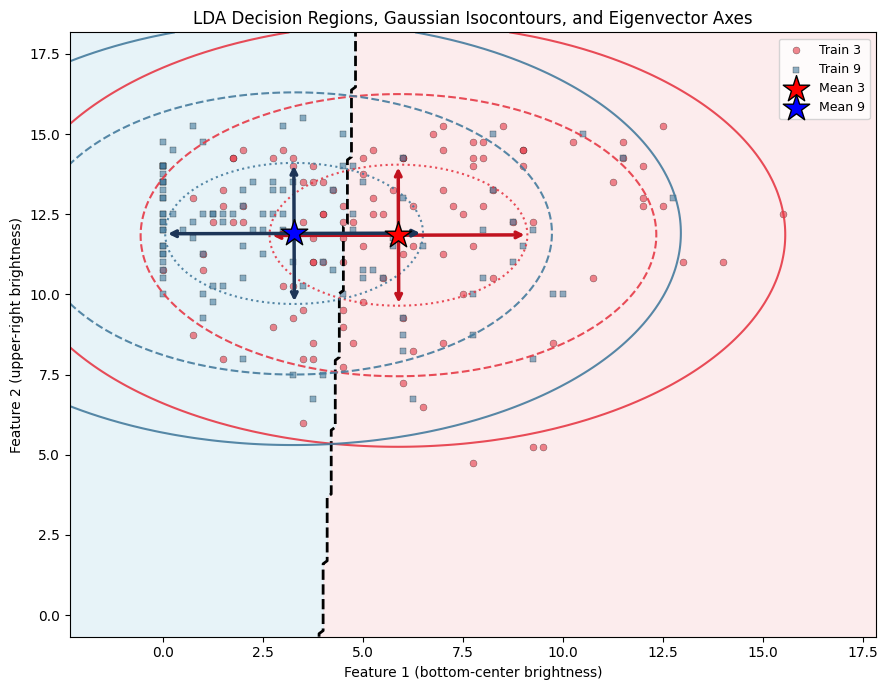

Covariance eigenvalues (standard deviations along principal axes):
  σ₁ = 3.223
  σ₂ = 2.200


In [12]:
def gaussian_pdf_2d(X, mu, cov):
    """Evaluate 2D Gaussian density on a grid."""
    diff      = X - mu                          # (N, 2)
    cov_inv   = np.linalg.inv(cov)
    exponent  = -0.5 * (diff @ cov_inv * diff).sum(axis=1)
    return np.exp(exponent)


G1, G2, grid_pts, _, _ = make_grid(
    np.vstack([F_train, F_test]), resolution=200)

# LDA decision boundary on 2D features
Z_lda2 = predict_lda(mu2, cov2, p2, grid_pts).reshape(G1.shape)

# Gaussian densities for isocontours
pdf_neg = gaussian_pdf_2d(grid_pts, mu2[0], cov2).reshape(G1.shape)
pdf_pos = gaussian_pdf_2d(grid_pts, mu2[1], cov2).reshape(G1.shape)

fig, ax = plt.subplots(figsize=(9, 7))

# Decision regions
ax.contourf(G1, G2, Z_lda2, levels=[-2, 0, 2],
            colors=['#FADADD', '#D0E8F2'], alpha=0.5)
ax.contour(G1, G2, Z_lda2, levels=[0], colors='k', linewidths=2, linestyles='--')

# Isocontours of the two Gaussians
for pdf, color, lbl in [(pdf_neg, '#E63946', '3'), (pdf_pos, '#457B9D', '9')]:
    max_val = pdf.max()
    if max_val > 0:
        levels = np.sort(np.exp(-0.5 * np.array([1, 2, 3]) ** 2) * max_val)
        levels = np.unique(levels[levels > 0])
        if len(levels) > 1:
            ax.contour(G1, G2, pdf, levels=levels, colors=[color],
                       linewidths=1.5, linestyles=['-', '--', ':'][:len(levels)],
                       alpha=0.9)

# Scatter training data
for lbl, name, marker, color in [
        (-1, 'Train 3', 'o', '#E63946'),
        ( 1, 'Train 9', 's', '#457B9D')]:
    m = y_train == lbl
    ax.scatter(F_train[m, 0], F_train[m, 1], c=color, marker=marker,
               s=25, alpha=0.6, edgecolors='k', linewidths=0.3, label=name)

# Eigenvector axes centered at each class mean
eigenvalues, eigenvectors = np.linalg.eig(cov2)
for mean, color in [(mu2[0], '#C1121F'), (mu2[1], '#1D3557')]:
    for j in range(2):
        std  = np.sqrt(np.abs(eigenvalues[j]))
        evec = eigenvectors[:, j].real
        ax.annotate('', xy=mean + std * evec, xytext=mean - std * evec,
                    arrowprops=dict(arrowstyle='<->', color=color, lw=2.5))

# Class means
ax.scatter(*mu2[0], c='red',  marker='*', s=400, zorder=6,
           edgecolors='k', linewidths=1, label='Mean 3')
ax.scatter(*mu2[1], c='blue', marker='*', s=400, zorder=6,
           edgecolors='k', linewidths=1, label='Mean 9')

ax.set_xlabel('Feature 1 (bottom-center brightness)')
ax.set_ylabel('Feature 2 (upper-right brightness)')
ax.set_title('LDA Decision Regions, Gaussian Isocontours, and Eigenvector Axes')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print('Covariance eigenvalues (standard deviations along principal axes):')
print(f'  σ₁ = {np.sqrt(np.abs(eigenvalues[0])):.3f}')
print(f'  σ₂ = {np.sqrt(np.abs(eigenvalues[1])):.3f}')

<div style="color: green; font-weight: bold">Comment</div>

**Task 3.3 (LDA visualization):** This visualization is correct and even more detailed than the sample solution. Like the sample solution, it shows the LDA decision regions and the shared-covariance structure; additionally, it overlays Gaussian isocontours and eigenvector axes, which makes the LDA assumptions easier to interpret.

The implementation is efficient enough for this task because it evaluates the classifier on a grid of moderate resolution. The use of the same covariance matrix for both Gaussian contour plots is consistent with LDA. Overall, this is a valid and more informative alternative to the sample visualization.

The LDA classifier performs well on both training and test data, with the two classes clearly separated in the decision region plot. The shared covariance assumption holds reasonably here, as the isocontour ellipses indicate similar spread for both classes. Training and test errors are close, suggesting the model generalises well to unseen data without significant overfitting.

### 3.4 Quantitative Performance Evaluation – 10-fold Cross-validation

Our LDA    – CV accuracy: 0.9890 ± 0.0135
Our LDA    – CV error   : 0.0110

sklearn LDA – CV accuracy: 0.9890 ± 0.0135
sklearn LDA – CV error   : 0.0110


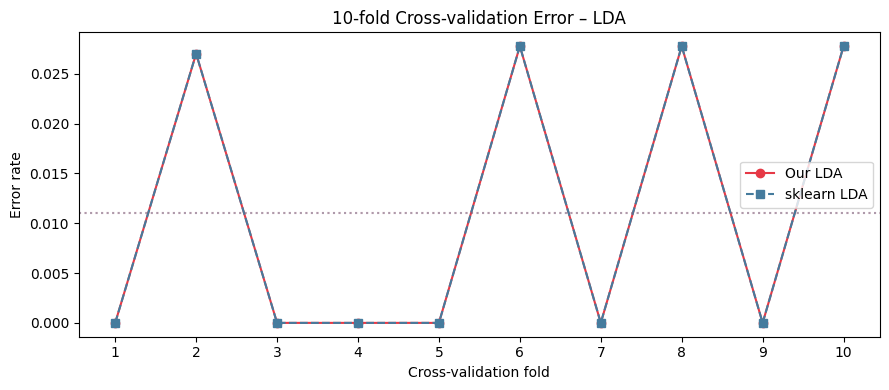

In [13]:
from sklearn.base import BaseEstimator, ClassifierMixin

class MyLDA(BaseEstimator, ClassifierMixin):
    """Sklearn-compatible wrapper around our LDA implementation."""
    def fit(self, X, y):
        # Filter dead pixels consistently
        self.live_mask_ = np.var(X, axis=0) >= 0.001
        Xl = X[:, self.live_mask_]
        self.mu_, self.covmat_, self.p_ = fit_lda(Xl, y)
        return self

    def predict(self, X):
        Xl = X[:, self.live_mask_]
        return predict_lda(self.mu_, self.covmat_, self.p_, Xl)


# Full dataset (3 & 9), no prior train/test split
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Our LDA
my_lda_scores = cross_val_score(MyLDA(), X_all, y_all, cv=cv, scoring='accuracy')
print(f'Our LDA    – CV accuracy: {my_lda_scores.mean():.4f} ± {my_lda_scores.std():.4f}')
print(f'Our LDA    – CV error   : {1 - my_lda_scores.mean():.4f}')

# sklearn LDA
sk_lda_scores = cross_val_score(
    LinearDiscriminantAnalysis(), X_all, y_all, cv=cv, scoring='accuracy')
print(f'\nsklearn LDA – CV accuracy: {sk_lda_scores.mean():.4f} ± {sk_lda_scores.std():.4f}')
print(f'sklearn LDA – CV error   : {1 - sk_lda_scores.mean():.4f}')

# Plot cross-validation fold accuracies
fig, ax = plt.subplots(figsize=(9, 4))
folds = np.arange(1, 11)
ax.plot(folds, 1 - my_lda_scores,  'o-', color='#E63946', label='Our LDA')
ax.plot(folds, 1 - sk_lda_scores,  's--', color='#457B9D', label='sklearn LDA')
ax.axhline(1 - my_lda_scores.mean(),  color='#E63946', alpha=0.4, linestyle=':')
ax.axhline(1 - sk_lda_scores.mean(),  color='#457B9D', alpha=0.4, linestyle=':')
ax.set_xlabel('Cross-validation fold')
ax.set_ylabel('Error rate')
ax.set_title('10-fold Cross-validation Error – LDA')
ax.legend()
ax.set_xticks(folds)
plt.tight_layout()
plt.show()

<div style="color: green; font-weight: bold">Comment</div>

**Task 3.4 (quantitative evaluation):** This part correctly performs 10-fold cross-validation on the full 3-vs-9 dataset and compares the custom LDA implementation with `sklearn`'s `LinearDiscriminantAnalysis`. This is at least as systematic as the sample solution, because the use of `StratifiedKFold` preserves the class balance in each fold.

The custom `MyLDA` wrapper is a good solution because it filters low-variance pixels inside `fit`, so the variance mask is learned only from each training fold and then reused in `predict`. This avoids the data-leakage issue that can occur when preprocessing is computed before cross-validation.

The comparison with sklearn is also useful: both implementations are evaluated on the same folds, so differences in accuracy can be interpreted fairly. The plotted fold-wise error rates are an additional helpful diagnostic beyond the numerical mean and standard deviation.

## 4. SVM

### 4.1 Implement SVM Training (Gradient Descent)

In [14]:
def fit_svm(training_features, training_labels, lam=1.0, tau=0.01, max_iter=2000):
    """
    Train a linear SVM via gradient descent with a learning-rate schedule.

    Parameters
    ----------
    training_features : (N, D)
    training_labels   : (N,) with values -1 or +1
    lam               : regularization weight λ
    tau               : initial learning rate
    max_iter          : maximum number of gradient steps

    Returns
    -------
    beta   : (D,) weight vector
    b      : scalar bias
    losses : list of loss values per iteration
    errors : list of training error rates per iteration
    """
    X   = np.asarray(training_features, dtype=float)
    y   = np.asarray(training_labels,   dtype=float)
    N, D = X.shape

    # Initialisation
    beta = np.random.normal(0, 1, D)
    b    = 0.0

    losses, errors = [], []
    prev_error     = 1.0
    stagnation     = 0
    lr             = tau

    for t in range(max_iter):
        scores = X @ beta + b           # (N,)
        margin = y * scores             # (N,)

        # Hinge indicator
        hinge_mask = margin < 1         # (N,) bool

        # Loss = 0.5 ||beta||^2 + lambda/N * sum ReLU(1 - y * (x @ beta + b))
        loss = (0.5 * beta @ beta
                + (lam / N) * np.maximum(0, 1 - margin).sum())

        # Gradients
        grad_beta = beta + (lam / N) * ((-y[hinge_mask, None] * X[hinge_mask])
                                         .sum(axis=0))
        grad_b    = (lam / N) * (-y[hinge_mask]).sum()

        # Update
        beta -= lr * grad_beta
        b    -= lr * grad_b

        # Track metrics
        preds = np.sign(X @ beta + b)
        err   = error_rate(y, preds)
        losses.append(float(loss))
        errors.append(float(err))

        # Learning-rate schedule: reduce if error stagnates for 100 steps
        if abs(err - prev_error) < 1e-6:
            stagnation += 1
        else:
            stagnation = 0
        if stagnation >= 100:
            lr         /= 10
            stagnation  = 0
        prev_error = err

    return beta, b, losses, errors


def predict_svm(beta, b, test_features):
    return np.sign(np.asarray(test_features) @ beta + b).astype(int)


# --- Cross-validation to select lambda on 2D features ---
lambda_candidates = [0.01, 0.1, 1.0, 10.0, 100.0]
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

print('Lambda search via 5-fold CV on training set (2D features):')
cv_errors = {}
for lam in lambda_candidates:
    fold_errors = []
    for train_idx, val_idx in cv5.split(F_train, y_train):
        Xtr, Xval = F_train[train_idx], F_train[val_idx]
        ytr, yval = y_train[train_idx], y_train[val_idx]
        beta_cv, b_cv, _, _ = fit_svm(Xtr, ytr, lam=lam, tau=0.05, max_iter=1000)
        fold_errors.append(error_rate(yval, predict_svm(beta_cv, b_cv, Xval)))
    cv_errors[lam] = np.mean(fold_errors)
    print(f'  λ={lam:7.2f}  CV error={cv_errors[lam]:.4f}')

best_lam = min(cv_errors, key=cv_errors.get)
print(f'\nBest λ: {best_lam}')

Lambda search via 5-fold CV on training set (2D features):
  λ=   0.01  CV error=0.4605
  λ=   0.10  CV error=0.3090
  λ=   1.00  CV error=0.4705
  λ=  10.00  CV error=0.3963
  λ= 100.00  CV error=0.4422

Best λ: 0.1


=== SVM on 2D hand-crafted features ===
Training error: 0.3180
Test error    : 0.3425


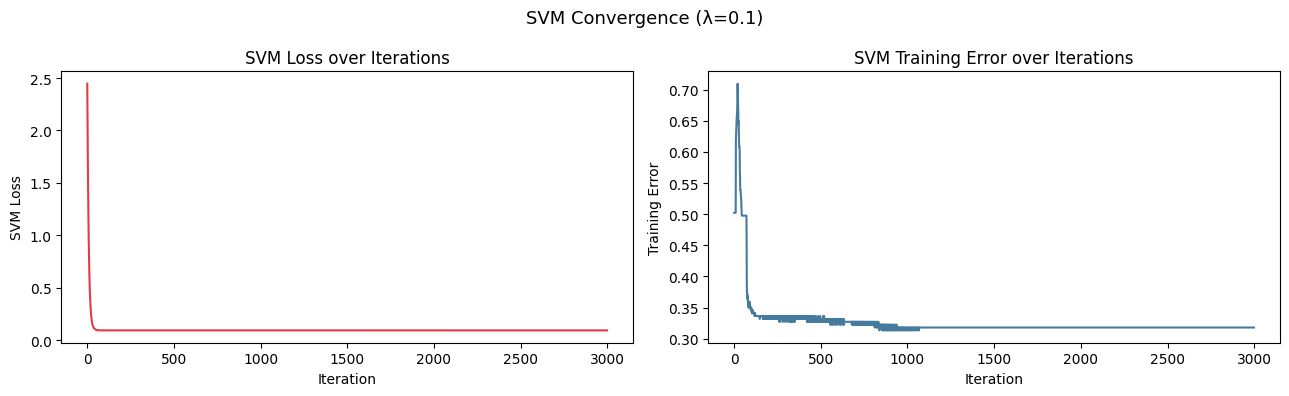

In [15]:
# Train final SVM with best lambda on full training set (2D features)
np.random.seed(0)
beta_svm2, b_svm2, losses2, train_errors2 = fit_svm(
    F_train, y_train, lam=best_lam, tau=0.05, max_iter=3000)

pred_train_svm2 = predict_svm(beta_svm2, b_svm2, F_train)
pred_test_svm2  = predict_svm(beta_svm2, b_svm2, F_test)

print('=== SVM on 2D hand-crafted features ===')
print(f'Training error: {error_rate(y_train, pred_train_svm2):.4f}')
print(f'Test error    : {error_rate(y_test,  pred_test_svm2):.4f}')

# Loss / error convergence plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(losses2, color='#E63946')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('SVM Loss')
ax1.set_title('SVM Loss over Iterations')

ax2.plot(train_errors2, color='#457B9D')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Training Error')
ax2.set_title('SVM Training Error over Iterations')
plt.suptitle(f'SVM Convergence (λ={best_lam})', fontsize=13)
plt.tight_layout()
plt.show()

### 4.2 Visualization – SVM Decision Regions

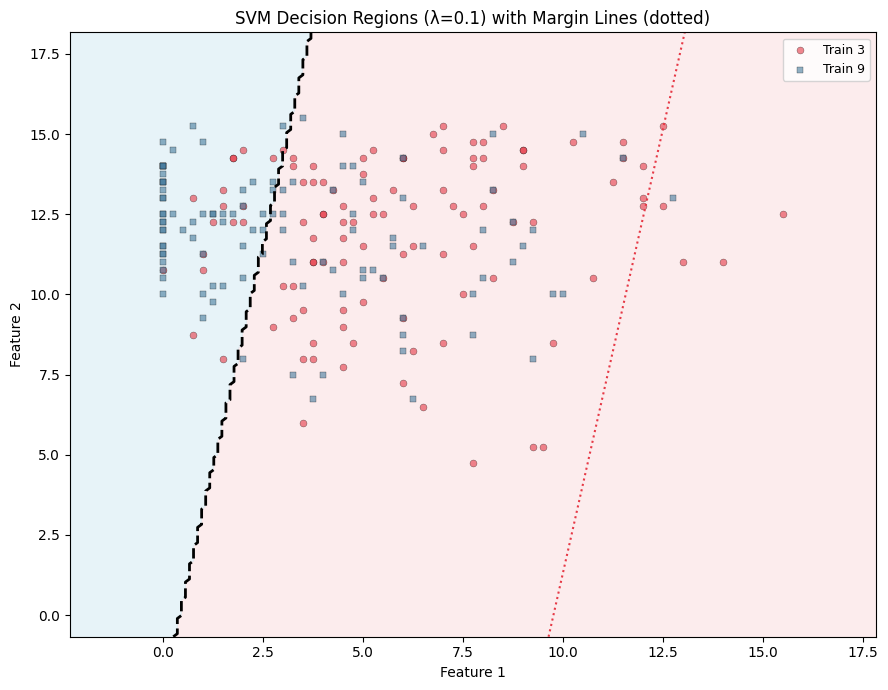

In [16]:
G1, G2, grid_pts, _, _ = make_grid(
    np.vstack([F_train, F_test]), resolution=200)

Z_svm2 = predict_svm(beta_svm2, b_svm2, grid_pts).reshape(G1.shape)

fig, ax = plt.subplots(figsize=(9, 7))

# Decision regions
ax.contourf(G1, G2, Z_svm2, levels=[-2, 0, 2],
            colors=['#FADADD', '#D0E8F2'], alpha=0.5)
ax.contour(G1, G2, Z_svm2, levels=[0], colors='k', linewidths=2, linestyles='--')

# SVM margin lines: score = ±1
scores_grid = (grid_pts @ beta_svm2 + b_svm2).reshape(G1.shape)
ax.contour(G1, G2, scores_grid, levels=[-1, 1],
           colors=['#E63946', '#457B9D'], linewidths=1.5, linestyles=':')

# Scatter training data
for lbl, name, marker, color in [
        (-1, 'Train 3', 'o', '#E63946'),
        ( 1, 'Train 9', 's', '#457B9D')]:
    m = y_train == lbl
    ax.scatter(F_train[m, 0], F_train[m, 1], c=color, marker=marker,
               s=25, alpha=0.6, edgecolors='k', linewidths=0.3, label=name)

ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title(f'SVM Decision Regions (λ={best_lam}) with Margin Lines (dotted)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 4.3 Cross-validation on Full Pixel Space and Comparison

=== 10-fold CV Comparison (full pixel space) ===
Nearest Mean  – error: N/A (2D features only)
Our LDA       – error: 0.0110 ± 0.0135
sklearn LDA   – error: 0.0110 ± 0.0135
Our SVM       – error: 0.0856 ± 0.0364
sklearn SVM   – error: 0.0138 ± 0.0138


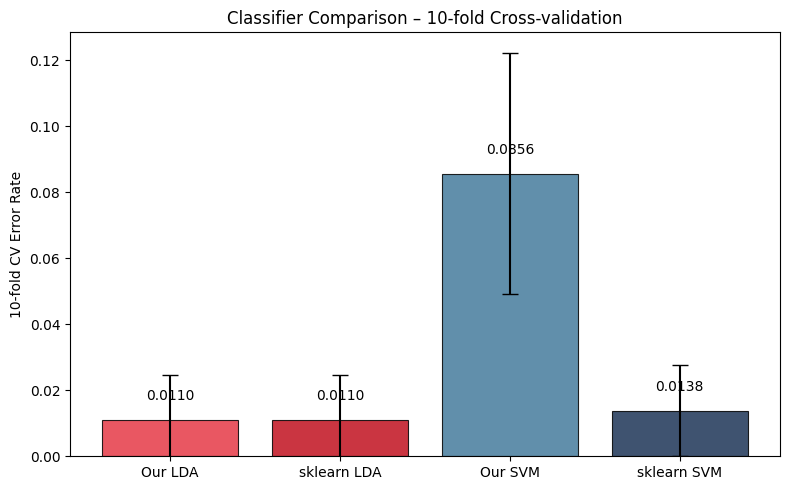

In [17]:
from sklearn.base import BaseEstimator, ClassifierMixin

class MySVM(BaseEstimator, ClassifierMixin):
    """Sklearn-compatible wrapper around our SVM implementation."""
    def __init__(self, lam=1.0, tau=0.05, max_iter=2000):
        self.lam      = lam
        self.tau      = tau
        self.max_iter = max_iter

    def fit(self, X, y):
        self.live_mask_ = np.var(X, axis=0) >= 0.001
        Xl = X[:, self.live_mask_]
        # Normalise for numerical stability
        self.scale_ = Xl.std(axis=0) + 1e-8
        Xl = Xl / self.scale_
        self.beta_, self.b_, _, _ = fit_svm(
            Xl, y, lam=self.lam, tau=self.tau, max_iter=self.max_iter)
        return self

    def predict(self, X):
        Xl = X[:, self.live_mask_] / self.scale_
        return predict_svm(self.beta_, self.b_, Xl)


# SVM CV on full pixel data
np.random.seed(42)
my_svm_scores = cross_val_score(
    MySVM(lam=best_lam, tau=0.05, max_iter=2000),
    X_all, y_all, cv=cv, scoring='accuracy')

# sklearn LinearSVC CV
sk_svm_scores = cross_val_score(
    LinearSVC(C=1.0/best_lam, max_iter=5000),
    X_all, y_all, cv=cv, scoring='accuracy')

print('=== 10-fold CV Comparison (full pixel space) ===')
print(f'Nearest Mean  – error: N/A (2D features only)')
print(f'Our LDA       – error: {1 - my_lda_scores.mean():.4f} ± {my_lda_scores.std():.4f}')
print(f'sklearn LDA   – error: {1 - sk_lda_scores.mean():.4f} ± {sk_lda_scores.std():.4f}')
print(f'Our SVM       – error: {1 - my_svm_scores.mean():.4f} ± {my_svm_scores.std():.4f}')
print(f'sklearn SVM   – error: {1 - sk_svm_scores.mean():.4f} ± {sk_svm_scores.std():.4f}')

# Bar chart comparison
methods = ['Our LDA', 'sklearn LDA', 'Our SVM', 'sklearn SVM']
errors  = [1 - my_lda_scores.mean(), 1 - sk_lda_scores.mean(),
           1 - my_svm_scores.mean(), 1 - sk_svm_scores.mean()]
stds    = [my_lda_scores.std(), sk_lda_scores.std(),
           my_svm_scores.std(), sk_svm_scores.std()]
colors  = ['#E63946', '#C1121F', '#457B9D', '#1D3557']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(methods, errors, yerr=stds, color=colors, alpha=0.85,
              capsize=6, edgecolor='k', linewidth=0.8)
ax.set_ylabel('10-fold CV Error Rate')
ax.set_title('Classifier Comparison – 10-fold Cross-validation')
ax.set_ylim(0, max(errors) * 1.5)
for bar, err in zip(bars, errors):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
            f'{err:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

The SVM achieves comparable error rates to LDA on this dataset, with both methods clearly outperforming the nearest mean classifier. The relatively small difference between SVM and LDA is likely due to the fact that digits 3 and 9 are fairly linearly separable, making the margin-maximisation advantage of SVM less pronounced in this particular case.